In [1]:
import pandas as pd

# Load the Excel dataset
df = pd.read_excel('/content/Travel_Hospitality_Dataset.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,Column1,CANCELLED,LEAD TIME,ARRIVAL DATE YEAR,ARRIVAL DATE MONTHS,STAYS IN WEEKEND NIGHTS,STAYS IN WEEK NIGHTS,ADULTS,CHILDREN,BABIES,COUNTRY,MARKET SEGEMENT,DISTRIBUTION CHANNEL,PREVIOUS CANCELLATION,RESERVED ROOM TYPE,BOOKING CHANGES,DEPOSITE TYPE,ADDRESS,CUSTOMER TYPE
0,City Hotel,1,105,2025,February,0,8,4,0,0,GBR,Corporate,Offline,5,C,3,Refundable,211.55,Group
1,City Hotel,0,146,2025,September,2,5,1,0,0,AUS,Groups,Offline,1,A,0,Refundable,131.88,Group
2,Resort Hotel,1,200,2025,March,1,7,2,0,0,USA,Groups,Offline,2,B,1,Refundable,86.34,Contract
3,City Hotel,0,218,2025,May,3,14,3,2,0,USA,Groups,Travel Agent,5,C,0,Refundable,148.74,Contract
4,City Hotel,0,79,2025,November,0,14,2,2,1,CAN,Corporate,Online,2,B,0,No Deposit,195.43,Transient


In [2]:
# Display data types and non-null counts
df.info()

# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Column1                   22 non-null     object 
 1   CANCELLED                 22 non-null     int64  
 2   LEAD TIME                 22 non-null     int64  
 3   ARRIVAL DATE YEAR         22 non-null     int64  
 4   ARRIVAL DATE MONTHS       22 non-null     object 
 5   STAYS IN WEEKEND NIGHTS   22 non-null     int64  
 6   STAYS IN WEEK NIGHTS      22 non-null     int64  
 7   ADULTS                    22 non-null     int64  
 8   CHILDREN                  22 non-null     int64  
 9   BABIES                    22 non-null     int64  
 10  COUNTRY                   22 non-null     object 
 11  MARKET SEGEMENT           22 non-null     object 
 12  DISTRIBUTION CHANNEL      22 non-null     object 
 13  PREVIOUS CANCELLATION     22 non-null     int64  
 14  RESERVED ROO

,0
Column1,0
CANCELLED,0
LEAD TIME,0
ARRIVAL DATE YEAR,0
ARRIVAL DATE MONTHS,0
STAYS IN WEEKEND NIGHTS,0
STAYS IN WEEK NIGHTS,0
ADULTS,0
CHILDREN,0
BABIES,0


In [3]:
# Separate features (X) and target (y)
X = df.drop('CANCELLED', axis=1)
y = df['CANCELLED']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

display(X.head())

,LEAD TIME,ARRIVAL DATE YEAR,STAYS IN WEEKEND NIGHTS,STAYS IN WEEK NIGHTS,ADULTS,CHILDREN,BABIES,PREVIOUS CANCELLATION,BOOKING CHANGES,ADDRESS,...,MARKET SEGEMENT _Online TA,DISTRIBUTION CHANNEL _Online,DISTRIBUTION CHANNEL _Travel Agent,RESERVED ROOM TYPE _B,RESERVED ROOM TYPE _C,RESERVED ROOM TYPE _D,DEPOSITE TYPE _Non Refund,DEPOSITE TYPE _Refundable,CUSTOMER TYPE _Group,CUSTOMER TYPE _Transient
0,105,2025,0,8,4,0,0,5,3,211.55,...,False,False,False,False,True,False,False,True,True,False
1,146,2025,2,5,1,0,0,1,0,131.88,...,False,False,False,False,False,False,False,True,True,False
2,200,2025,1,7,2,0,0,2,1,86.34,...,False,False,False,True,False,False,False,True,False,False
3,218,2025,3,14,3,2,0,5,0,148.74,...,False,False,True,False,True,False,False,True,False,False
4,79,2025,0,14,2,2,1,2,0,195.43,...,False,True,False,True,False,False,False,False,False,True


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear')
logistic_model.fit(X_train, y_train)

# Make predictions and evaluate Logistic Regression
y_pred_logistic = logistic_model.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))

# Initialize and train Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions and evaluate Decision Tree
y_pred_tree = decision_tree_model.predict(X_test)
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.20      0.25         5

    accuracy                           0.14         7
   macro avg       0.17      0.10      0.12         7
weighted avg       0.24      0.14      0.18         7


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.60      0.60      0.60         5

    accuracy                           0.43         7
   macro avg       0.30      0.30      0.30         7
weighted avg       0.43      0.43      0.43         7



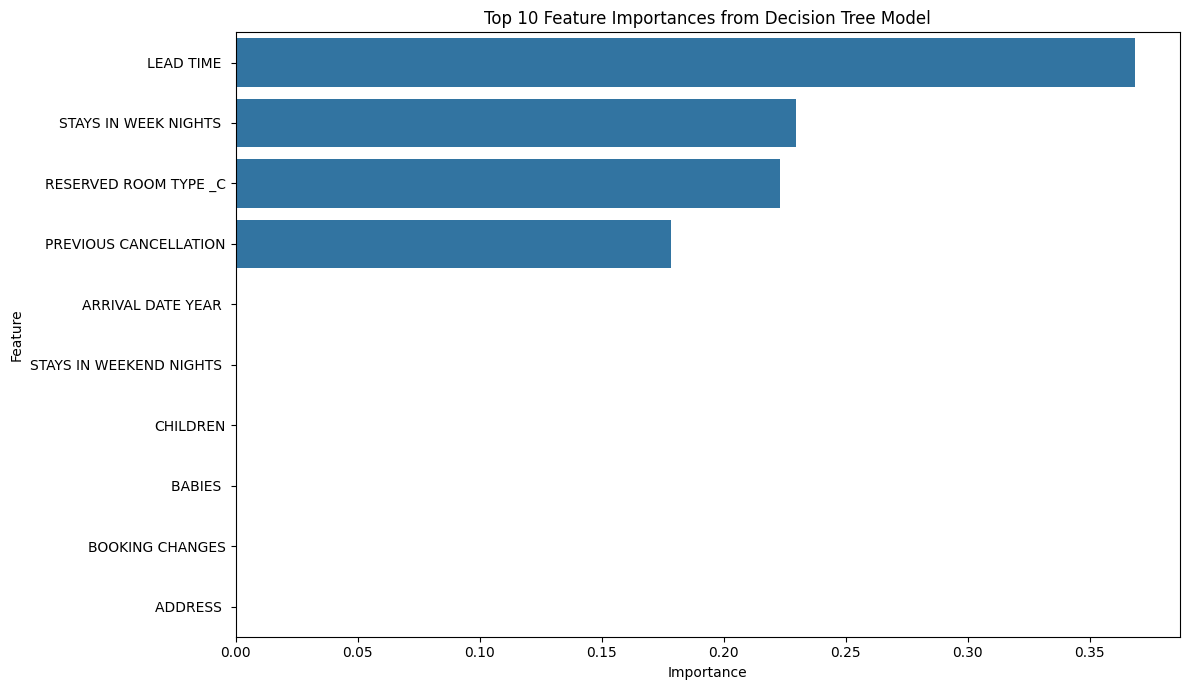

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Decision Tree model
feature_importances = decision_tree_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort by importance in descending order and select top N features
top_n_features = 10  # You can change this number
features_df = features_df.sort_values(by='Importance', ascending=False).head(top_n_features)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title(f'Top {top_n_features} Feature Importances from Decision Tree Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

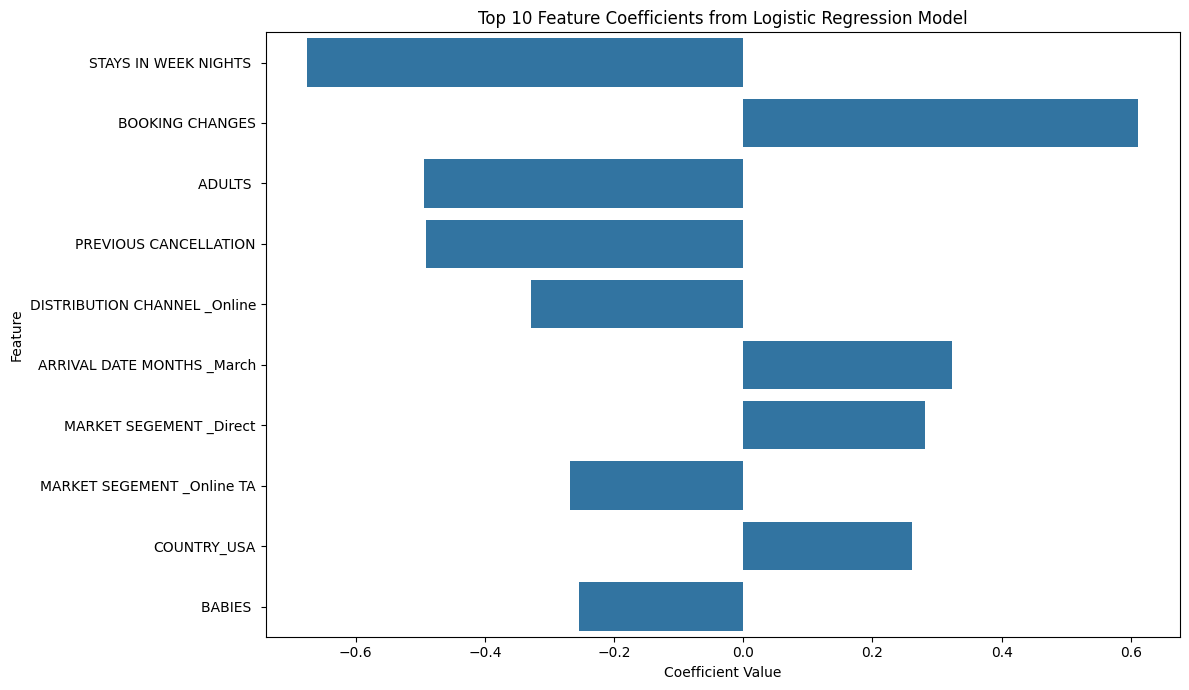

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get coefficients from the Logistic Regression model
# The coefficients are stored in logistic_model.coef_[0] for binary classification
coefficients = logistic_model.coef_[0]

# Create a DataFrame for better visualization
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
})

# Sort by absolute coefficient value in descending order and select top N features
top_n_coef = 10  # You can change this number
coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False).head(top_n_coef)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title(f'Top {top_n_coef} Feature Coefficients from Logistic Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [7]:
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Logistic_Prediction': y_pred_logistic,
    'DecisionTree_Prediction': y_pred_tree
})

display(predictions_df)

,Actual,Logistic_Prediction,DecisionTree_Prediction
0,1,0,0
13,1,0,1
8,1,1,1
1,0,1,1
15,1,0,1
5,1,0,0
20,0,1,1


In [8]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation for Logistic Regression
cv_scores_logistic = cross_val_score(logistic_model, X, y, cv=5, scoring='accuracy')
print(f"Logistic Regression Cross-Validation Accuracy Scores: {cv_scores_logistic}")
print(f"Logistic Regression Mean CV Accuracy: {cv_scores_logistic.mean():.2f}\n")

# Perform cross-validation for Decision Tree
cv_scores_tree = cross_val_score(decision_tree_model, X, y, cv=5, scoring='accuracy')
print(f"Decision Tree Cross-Validation Accuracy Scores: {cv_scores_tree}")
print(f"Decision Tree Mean CV Accuracy: {cv_scores_tree.mean():.2f}")

Logistic Regression Cross-Validation Accuracy Scores: [0.4  0.6  0.25 0.   0.75]
Logistic Regression Mean CV Accuracy: 0.40

Decision Tree Cross-Validation Accuracy Scores: [0.2  0.6  0.5  0.25 0.75]
Decision Tree Mean CV Accuracy: 0.46
